<a href="https://colab.research.google.com/github/AliceFranca0/tcc-deteccao-fake-news-ptbr/blob/main/Fase2_Limpeza_Vazamento_Classificadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2 — Limpeza, Vazamento de Dados e Classificadores Baseline

Esta fase prepara os dados para modelagem, investiga riscos de vazamento de informação e treina os dois classificadores clássicos que servem de linha de base para a comparação com o BERTimbau (Fase 5).

Continuação a partir de `dados/fakerecogna_bruto.csv` (Fase 1).

## 1. Ambiente

In [ ]:
!pip install -q scikit-learn nltk joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/TCC"

import os
os.makedirs(f"{BASE}/dados", exist_ok=True)
os.makedirs(f"{BASE}/figuras", exist_ok=True)
os.makedirs(f"{BASE}/modelos", exist_ok=True)

print("Pastas prontas em", BASE)

Mounted at /content/drive
Pastas prontas em /content/drive/MyDrive/TCC


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

CORAL = "#EF476F"   # Fake
AZUL = "#118AB2"    # Real

mpl.rcParams.update({
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#073B4C",
    "axes.labelsize": 10.5,
    "axes.labelweight": "bold",
    "axes.edgecolor": "#999999",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv(f"{BASE}/dados/fakerecogna_bruto.csv")
print(f"{len(df)} linhas carregadas")

11903 linhas carregadas


## 2. Limpeza

In [ ]:
antes = len(df)
df = df.dropna(subset=["Noticia", "Classe", "Categoria", "URL"]).reset_index(drop=True)
df["Classe"] = df["Classe"].astype(int)
print(f"Removidos {antes - len(df)} registros incompletos | Restam {len(df)}")

Removidos 1 registros incompletos | Restam 11902


## 3. Verificação de vazamento — campo Subtítulo

Hipótese: a presença do subtítulo reflete a origem editorial da notícia, não o seu conteúdo. Se a distribuição diferir muito entre as classes, o campo constitui vazamento e não pode ser usado como atributo.

               FAKE  REAL
SEM SUBTÍTULO  24.7  81.5
COM SUBTÍTULO  75.3  18.5


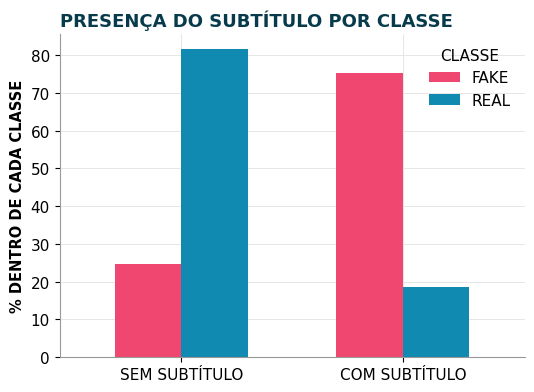

In [ ]:
df["tem_subtitulo"] = df["Subtitulo"].notna()

tabela_leak = pd.crosstab(df["tem_subtitulo"], df["Classe"], normalize="columns") * 100
tabela_leak.index = ["SEM SUBTÍTULO", "COM SUBTÍTULO"]
tabela_leak.columns = ["FAKE", "REAL"]
print(tabela_leak.round(1))

fig, ax = plt.subplots(figsize=(6, 4.2))
tabela_leak.plot(kind="bar", ax=ax, color=[CORAL, AZUL], width=0.6)
ax.set_title("PRESENÇA DO SUBTÍTULO POR CLASSE", loc="left")
ax.set_ylabel("% DENTRO DE CADA CLASSE")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="CLASSE")
plt.savefig(f"{BASE}/figuras/verificacao_leakage_subtitulo.png")
plt.show()

**Decisão metodológica:** `Subtitulo` e `tem_subtitulo` são excluídos do conjunto de atributos. A diferença observada entre as classes decorre de práticas editoriais das fontes, não de propriedades do conteúdo — usá-los inflaria artificialmente o desempenho.

## 4. Tratamento da coluna Data

In [ ]:
def extrair_data(texto):
    if pd.isna(texto):
        return pd.NaT
    texto = str(texto)
    for padrao in [r"(\d{1,2})[/-](\d{1,2})[/-](\d{4})", r"(\d{4})[/-](\d{1,2})[/-](\d{1,2})"]:
        m = re.search(padrao, texto)
        if m:
            g = m.groups()
            ano, mes, dia = (g[2], g[1], g[0]) if len(g[0]) <= 2 else (g[0], g[1], g[2])
            try:
                return pd.Timestamp(year=int(ano), month=int(mes), day=int(dia))
            except (ValueError, pd.errors.OutOfBoundsDatetime):
                return pd.NaT
    return pd.NaT

df["data_tratada"] = df["Data"].apply(extrair_data)
n_ok = df["data_tratada"].notna().sum()
print(f"Datas convertidas: {n_ok}/{len(df)} ({n_ok/len(df)*100:.1f}%)")

Datas convertidas: 11327/11902 (95.2%)


Os formatos de data são inconsistentes no corpus original. Registros cuja data não pôde ser reconhecida com segurança ficam como nulos — preferível a inferir datas incorretas.

## 5. Divisão treino/teste

A semente `random_state=42` e a proporção 80/20 estratificada são mantidas idênticas na Fase 5 (BERTimbau). Sem isso, a comparação entre os modelos não teria validade metodológica.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["Noticia"]
y = df["Classe"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")
print("Proporção no teste:", y_test.value_counts(normalize=True).round(3).to_dict())

Treino: 9521 | Teste: 2381
Proporção no teste: {0: 0.5, 1: 0.5}


## 6. Vetorização TF-IDF

In [ ]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

vetorizador = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=stopwords.words("portuguese"),
    min_df=5,
)

X_train_tfidf = vetorizador.fit_transform(X_train)
X_test_tfidf = vetorizador.transform(X_test)
print(f"Treino: {X_train_tfidf.shape} | Teste: {X_test_tfidf.shape}")

Treino: (9521, 5000) | Teste: (2381, 5000)


## 7. Treinamento — Logistic Regression e Random Forest

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_tfidf, y_train)
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train_tfidf, y_train)
print("Modelos treinados.")

Modelos treinados.


## 8. Avaliação

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for nome, modelo in [("Logistic Regression", modelo_lr), ("Random Forest", modelo_rf)]:
    pred = modelo.predict(X_test_tfidf)
    print(f"\n{'='*55}\n{nome} — Acurácia: {accuracy_score(y_test, pred):.4f}\n{'='*55}")
    print(classification_report(y_test, pred, target_names=["Fake (0)", "Real (1)"], digits=4))


Logistic Regression — Acurácia: 0.9437
              precision    recall  f1-score   support

    Fake (0)     0.9475    0.9395    0.9435      1191
    Real (1)     0.9400    0.9479    0.9439      1190

    accuracy                         0.9437      2381
   macro avg     0.9438    0.9437    0.9437      2381
weighted avg     0.9438    0.9437    0.9437      2381


Random Forest — Acurácia: 0.9374
              precision    recall  f1-score   support

    Fake (0)     0.9334    0.9421    0.9377      1191
    Real (1)     0.9415    0.9328    0.9371      1190

    accuracy                         0.9374      2381
   macro avg     0.9375    0.9374    0.9374      2381
weighted avg     0.9375    0.9374    0.9374      2381



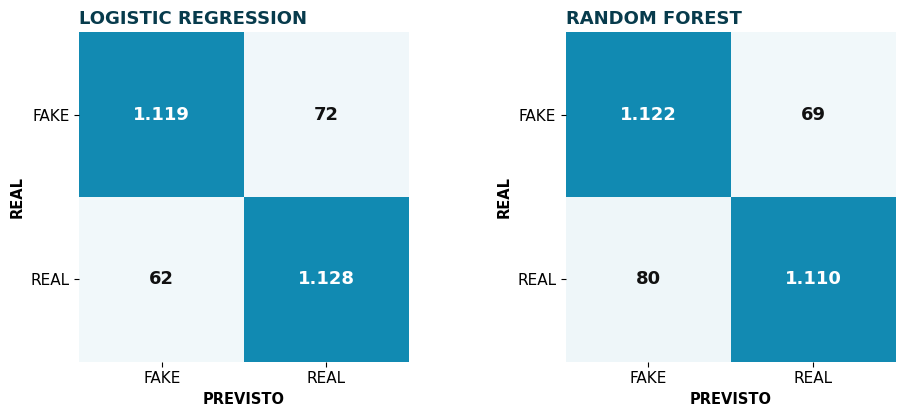

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("vivido", ["#FFFFFF", AZUL])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, (nome, modelo) in zip(axes, [("LOGISTIC REGRESSION", modelo_lr), ("RANDOM FOREST", modelo_rf)]):
    cm = confusion_matrix(y_test, modelo.predict(X_test_tfidf))
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            cor = "white" if cm[i, j] > cm.max() * 0.55 else "#111111"
            ax.text(j, i, f"{cm[i, j]:,}".replace(",", "."), ha="center", va="center",
                    fontsize=13, color=cor, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["FAKE", "REAL"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["FAKE", "REAL"])
    ax.set_xlabel("PREVISTO"); ax.set_ylabel("REAL")
    ax.set_title(nome, loc="left")
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.savefig(f"{BASE}/figuras/matrizes_confusao.png")
plt.show()

## 9. Termos mais discriminativos

A Logistic Regression permite inspecionar diretamente o peso de cada termo, o que oferece uma primeira leitura de interpretabilidade — aprofundada na Fase 7 com LIME.

In [ ]:
nomes = np.array(vetorizador.get_feature_names_out())
coef = modelo_lr.coef_[0]

print("Termos associados a FAKE:")
print(", ".join(nomes[np.argsort(coef)[:20]]))
print("\nTermos associados a REAL:")
print(", ".join(nomes[np.argsort(coef)[-20:][::-1]]))

Termos associados a FAKE:
circular, circular rede, compartilhar, mensagem, umar, pra, parir, texto, vídeo, rede social, facebook, verdade, rede, 00, pelar, publicação, fake, checar, falso, site

Termos associados a REAL:
feira, coronavírus, hoje, pandemia, caso, pandemia coronavírus, decisão, saudar, ministério, uol, íntegro, ler íntegro, contar, país, segunda, jair bolsonaro, segunda feira, covid 19, jair, capital


## 10. Persistência dos modelos

O vetorizador e os dois classificadores são salvos para que a Fase 6 possa submetê-los ao corpus de notícias sintéticas sem retreinar.

In [ ]:
import joblib

joblib.dump(vetorizador, f"{BASE}/modelos/vetorizador_tfidf.pkl")
joblib.dump(modelo_lr, f"{BASE}/modelos/modelo_logistic_regression.pkl")
joblib.dump(modelo_rf, f"{BASE}/modelos/modelo_random_forest.pkl")
print("Modelos salvos em", f"{BASE}/modelos/")

Modelos salvos em /content/drive/MyDrive/TCC/modelos/


## 11. Exportação dos resultados

In [ ]:
indices = X_test.index

resultados = pd.DataFrame({
    "titulo": df.loc[indices, "Titulo"].values,
    "categoria": df.loc[indices, "Categoria"].values,
    "data": df.loc[indices, "data_tratada"].values,
    "n_palavras": df.loc[indices, "n_palavras_noticia"].values,
    "classe_real": y_test.values,
    "previsao_logistic_regression": modelo_lr.predict(X_test_tfidf),
    "previsao_random_forest": modelo_rf.predict(X_test_tfidf),
})
resultados["acertou_lr"] = resultados["classe_real"] == resultados["previsao_logistic_regression"]
resultados["acertou_rf"] = resultados["classe_real"] == resultados["previsao_random_forest"]
resultados["classe_real_label"] = resultados["classe_real"].map({0: "Fake", 1: "Real"})

resultados.to_csv(f"{BASE}/dados/resultados_classificacao.csv", index=False, encoding="utf-8-sig")
print(f"{len(resultados)} previsões exportadas")
resultados.head()

2381 previsões exportadas


,titulo,categoria,data,n_palavras,classe_real,previsao_logistic_regression,previsao_random_forest,acertou_lr,acertou_rf,classe_real_label
0,\n\nBolsonaro vai a orfanato e pergunta como f...,política,2021-08-10,39.0,0,0,0,True,True,Fake
1,Brasil registra 10.278 casos confirmados de co...,saúde,2020-04-04,112.0,1,1,1,True,True,Real
2,\n\nCarol Solberg é patrocinada pelo Banco do ...,entretenimento,NaT,142.0,0,0,0,True,True,Fake
3,Fachin quer mudar de turma no STF; relatoria d...,política,2021-04-15,73.0,1,1,1,True,True,Real
4,Idoso com suspeita de covid-19 foge de hospita...,saúde,2020-06-21,103.0,1,1,1,True,True,Real
